# Phase 0 — Baselines: what must every model beat?

**Before any model: how well do naive, points-only predictors rank next-gameweek returns, within each position?**

_Read-only benchmark — Phase 0 of [docs/predictive-layer-plan.md](../../docs/predictive-layer-plan.md). No model here; this fixes the floor every later model is measured against._
Population: `minutes > 0`, **DGW excluded**, evaluate GW > 3; leakage-safe walk-forward — each prediction uses only strictly-prior gameweeks (an expanding, uncapped history), leakage-checked.

> **How to read.** Each baseline predicts a player's points from that player's **strictly-prior** gameweeks only (leakage-safe). We score **ranking**, not exact points, because FPL is won by ranking players and the target is zero-inflated/right-skewed.

> **Ranking is within-position only.** Squads fill under position quotas (2 GK / 5 DEF / 5 MID / 3 FWD), so ranking a keeper against a forward is meaningless — **cross-position pooling is abolished**. Metrics: within-(GW, position) **Spearman**, tie-aware **precision@k**, **NDCG@k** (k scaled per position). Absolute-error (MAE) is *not* a leaderboard metric — the target is too haul-noisy to compare models by; RMSE is omitted for the same reason.

> **Conditional on appearance.** Metrics cover players who *actually featured* — availability is treated as known. This is *ranking given the player played*, a valid sub-problem, **not** end-to-end forecast accuracy (predicting who plays is the availability family's job).

## Setup
> Load the mart, apply the population filter, and pull the per-position benchmark. All numbers come from `model.eval` — the notebook only renders them.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from dal.pipeline import load as load_mart, run as run_pipeline
from dal.exceptions import MartNotBuiltError, MartSchemaError
from model.eval import per_gw_scores, walk_forward_by_position
from model.eval.baselines import BASELINES, build_baseline_features
from model.eval.walkforward import POSITIONS, WARMUP_GW

BASELINE_COLOUR = {
    'expanding season avg': '#1f77b4', 'rolling avg (5)': '#2ca02c', 'rolling avg (3)': '#98df8a',
    'last-GW points': '#ff7f0e',
}

try:
    loaded = load_mart()
except (MartNotBuiltError, MartSchemaError) as err:
    print(f'Rebuilding mart ({type(err).__name__})...')
    run_pipeline(force=True)
    loaded = load_mart()
mart = loaded.mart

features = build_baseline_features(mart)
by_pos = walk_forward_by_position(mart)
common_n = int(features[list(BASELINES)].notna().all(axis=1).sum())
print(f'Study range: GW 1 - {loaded.data_cutoff_gw} | minutes > 0 | DGW excluded | common eval n = {common_n:,}')

Study range: GW 1 - 38 | minutes > 0 | DGW excluded | common eval n = 8,728


## Per-position benchmark — the real bars to beat
> Ranking quality varies ~5x across positions, so there is **no pooled number** — each position gets its own bar. **GK is near chance** (clean-sheet/fixture driven, not player persistence — echoing the diagnostic layer's GK abstentions). **MID and FWD are the rankable positions**; FWD is the one place recent form (**rolling-5**) beats season class. These per-position bars gate Phase 1.

spearman  precision_at_k  ndcg_at_k   k  n_gw
position baseline                                                           
GK       rolling avg (5)         0.0619          0.2803     0.4299   4    33
         last-GW points          0.0352          0.2576     0.4127   4    33
         rolling avg (3)         0.0349          0.2879     0.4400   4    33
         expanding season avg    0.0236          0.3258     0.4573   4    33
DEF      expanding season avg    0.1671          0.3500     0.4383  20    33
         rolling avg (5)         0.1312          0.3242     0.4191  20    33
         rolling avg (3)         0.1015          0.3076     0.3889  20    33
         last-GW points          0.0829          0.2788     0.3685  20    33
MID      expanding season avg    0.3114          0.2985     0.4414  20    33
         rolling avg (5)         0.2793          0.2864     0.4209  20    33
         rolling avg (3)         0.2691          0.2515     0.4084  20    33
         last-GW points          0.2450          0.2394     0.3849  20    33
FWD      rolling avg (5)         0.3339          0.4811     0.4869   8    33
         expanding season avg    0.3175          0.4811     0.4946   8    33
         rolling avg (3)         0.3005          0.4659     0.4692   8    33
         last-GW points          0.2895          0.4659     0.4535   8    33

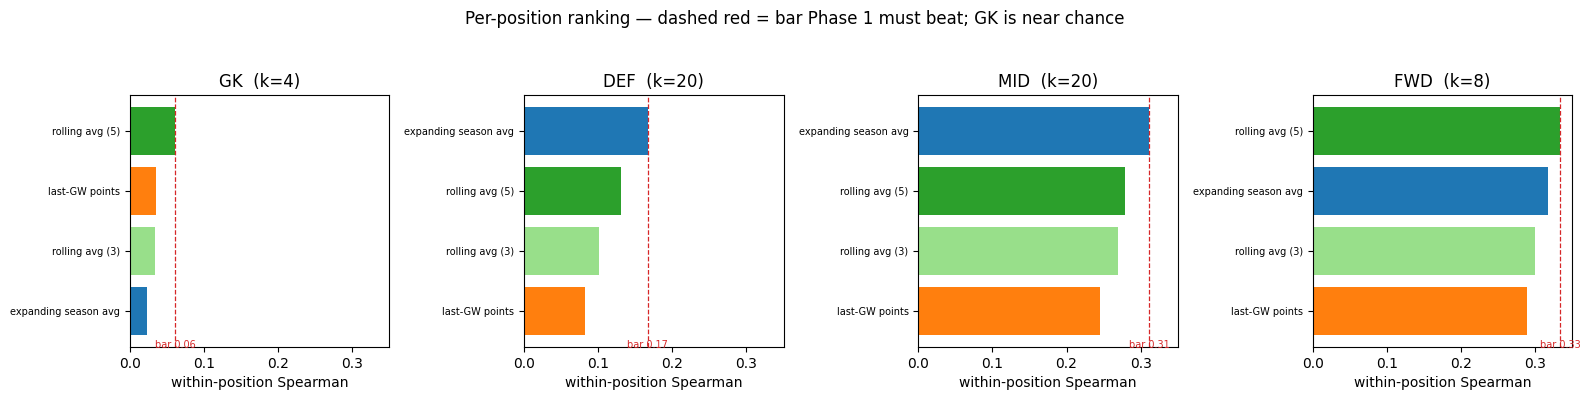

In [5]:
display(by_pos.round(4))

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), sharex=True)
for ax, pos in zip(axes, POSITIONS):
    sub = by_pos.xs(pos, level='position').sort_values('spearman')
    labels = sub.index
    ax.barh(np.arange(len(labels)), sub['spearman'].fillna(0.0), color=[BASELINE_COLOUR[b] for b in labels])
    best = sub['spearman'].max()
    ax.axvline(best, color='#d62728', ls='--', lw=0.9)
    ax.text(best, -0.6, f'bar {best:.2f}', color='#d62728', fontsize=7, ha='center')
    ax.set_yticks(np.arange(len(labels))); ax.set_yticklabels(labels, fontsize=7)
    ax.set_title(f'{pos}  (k={int(sub["k"].iloc[0])})'); ax.axvline(0, color='k', lw=0.5)
    ax.set_xlabel('within-position Spearman')
fig.suptitle('Per-position ranking — dashed red = bar Phase 1 must beat; GK is near chance', y=1.04)
plt.tight_layout(); plt.show()

## Per-gameweek view — the substrate behind the summary
> The bars above are **season means**. `per_gw_scores` exposes the same metrics *per gameweek* — the fine-grained table the summary aggregates (the season Spearman is literally the mean of these lines, and the CI is a block-bootstrap over them). Reading week-to-week shows **how noisy a single GW is** and whether a baseline's edge is persistent or fragile. Pick a position; each line is a baseline, each point a gameweek.

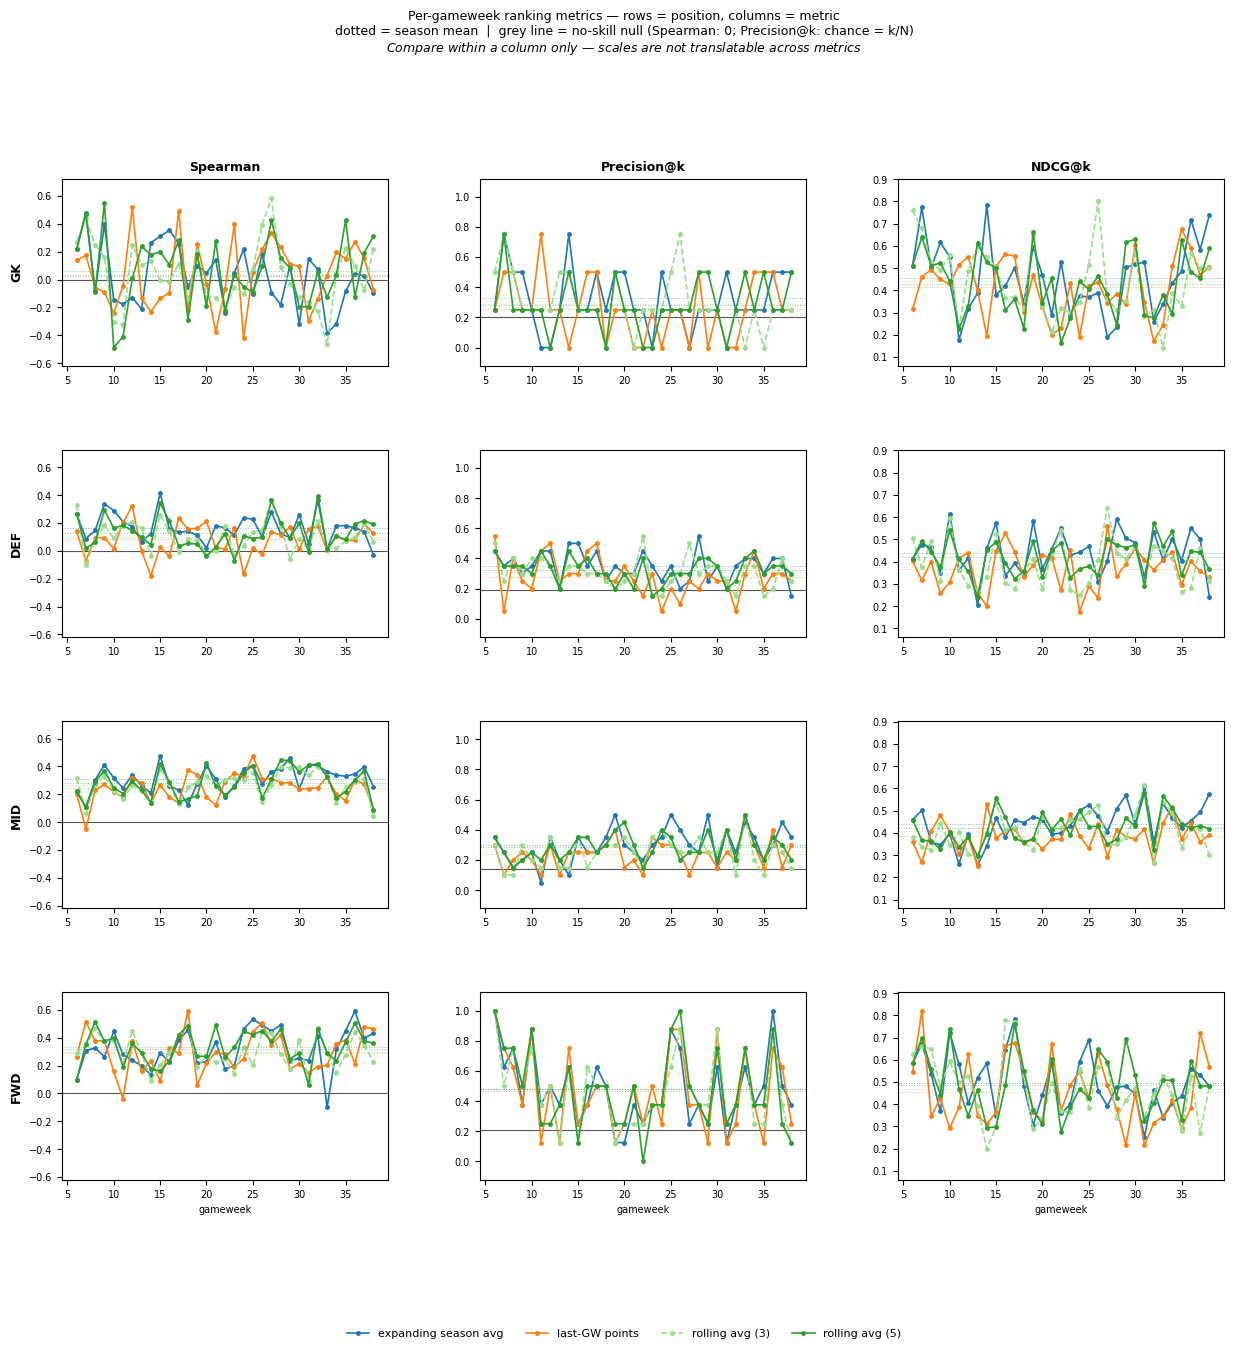

In [6]:
long = per_gw_scores(features[features['gw'] > WARMUP_GW], BASELINES)

METRICS = ['spearman', 'precision_at_k', 'ndcg_at_k']
METRIC_LABELS = ['Spearman', 'Precision@k', 'NDCG@k']
# Differentiate the two similar rolling lines by style so they're distinguishable without colour alone.
LINESTYLE = {'rolling avg (3)': '--', 'rolling avg (5)': '-'}

fig, axes = plt.subplots(4, 3, figsize=(15, 13), sharey=False, sharex=False)
fig.subplots_adjust(hspace=0.45, wspace=0.28)

# y-limits per metric column — computed once across all positions so within-column scale is shared.
col_ylims = {}
for ci, metric in enumerate(METRICS):
    vals = long[metric].dropna()
    pad = (vals.max() - vals.min()) * 0.12 or 0.05
    col_ylims[ci] = (vals.min() - pad, vals.max() + pad)

post = features[features['gw'] > WARMUP_GW]

for ri, pos in enumerate(('GK', 'DEF', 'MID', 'FWD')):
    sub = long[long['position'] == pos]
    k_val = int(sub['k'].median()) if not sub.empty else 4
    # base rate = k / median players in this position per GW (from raw features, not the long frame)
    pos_pool = post[post['position'] == pos].groupby('gw').size().median()
    base_rate = k_val / pos_pool if pos_pool > 0 else None

    for ci, (metric, mlabel) in enumerate(zip(METRICS, METRIC_LABELS)):
        ax = axes[ri][ci]
        for label, gp in sub.groupby('model'):
            gp = gp.sort_values('gw')
            ls = LINESTYLE.get(label, '-')
            ax.plot(gp['gw'], gp[metric], ls=ls, marker='o', ms=2.5, lw=1.2,
                    color=BASELINE_COLOUR.get(label), label=label if ri == 0 else None)
            ax.axhline(gp[metric].mean(), color=BASELINE_COLOUR.get(label), ls=':', lw=0.7, alpha=0.55)

        # Per-metric null reference line.
        if ci == 0:
            ax.axhline(0, color='#555555', lw=0.8, ls='-', zorder=0)       # Spearman no-skill = 0
        elif ci == 1 and base_rate is not None:
            ax.axhline(base_rate, color='#555555', lw=0.8, ls='-', zorder=0)  # prec@k chance = k/N
        # NDCG@k: no single universal null (random ordering scores high due to discounting + ties);
        # omit the line and let relative movement between baselines tell the story.

        ax.set_ylim(col_ylims[ci])
        if ri == 0:
            ax.set_title(mlabel, fontsize=9, fontweight='bold')
        if ci == 0:
            ax.set_ylabel(pos, fontsize=9, fontweight='bold')
        ax.set_xlabel('gameweek' if ri == 3 else '', fontsize=7)
        ax.tick_params(labelsize=7)

# Single shared legend from the top row, first panel.
handles, labels_ = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels_, loc='lower center', ncol=4, fontsize=8,
           frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.suptitle(
    'Per-gameweek ranking metrics — rows = position, columns = metric\n'
    'dotted = season mean  |  grey line = no-skill null (Spearman: 0; Precision@k: chance = k/N)\n'
    r'$\it{Compare\ within\ a\ column\ only\ —\ scales\ are\ not\ translatable\ across\ metrics}$',
    fontsize=9, y=1.01,
)
plt.show()

## Summary — the bars Phase 1 must beat

| position | bar (within-position Spearman) | read |
|---|---|---|
| GK | ~0.06 | near chance — history barely ranks keepers |
| DEF | 0.17 | middling |
| MID | 0.31 | rankable |
| FWD | 0.33 | most rankable; rolling-5 > season-avg |

**What it establishes.** *Level persists* (season avg best) and *deviations mean-revert* (last-GW worst, smoothing helps). The frozen numbers live in [docs/studies/results/predictive-phase0-baselines.md](../../docs/studies/results/predictive-phase0-baselines.md).

**Gate.** A Phase-1 model earns promotion only by beating these **per-position** bars on this same walk-forward harness. There is no pooled number to game.

## What the per-gameweek view tells us

> These conclusions are scoped to **points history only** — what past scores can and cannot predict. They do not say what *does* drive GK points, or what a better model should use. That is Phase 2+.

**GK — history is nearly useless for ranking keepers.**
How a keeper scored last week, or all season, tells you almost nothing about how they'll score next week. We can't conclude *why* from this data — only that past points don't help. Don't rank keeper options by points history.

**DEF — season average is the most reliable guide; last week is the worst.**
Defenders who consistently accumulate points across the season are more predictable than form-chasers. "Season average" here means the running average of a player's points up to — but not including — the current gameweek. Last week's score is the least useful signal.

**MID — the most rankable position.**
A midfielder's points history is a meaningful signal for next week, more so than any other position. The season average is the best single guide.

**FWD — the one position where recent form edges out season average.**
Rolling form over the last 3–5 gameweeks is a slightly better predictor than the full season average for forwards. This is the only position where that is true.

**Everywhere: last week's score is the least useful signal.**
A single blank or haul tells you very little. The signal only becomes reliable across many gameweeks — which is why the season average consistently outperforms last-GW points at three of four positions.